### Testing inference

In [ ]:
import os
import numpy as np
import torch
from torchvision.transforms import transforms
from stormer.data.iterative_dataset import ERA5MultiLeadtimeDataset
from stormer.models.iterative_module import GlobalForecastIterativeModule
from stormer.models.hub.stormer import Stormer
from stormer.data.multi_step_datamodule import collate_fn_val
from torch.utils.data import DataLoader

variables = [
    "2m_temperature",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "mean_sea_level_pressure",
    "geopotential_50",
    "geopotential_100",
    "geopotential_150",
    "geopotential_200",
    "geopotential_250",
    "geopotential_300",
    "geopotential_400",
    "geopotential_500",
    "geopotential_600",
    "geopotential_700",
    "geopotential_850",
    "geopotential_925",
    "geopotential_1000",
    "u_component_of_wind_50",
    "u_component_of_wind_100",
    "u_component_of_wind_150",
    "u_component_of_wind_200",
    "u_component_of_wind_250",
    "u_component_of_wind_300",
    "u_component_of_wind_400",
    "u_component_of_wind_500",
    "u_component_of_wind_600",
    "u_component_of_wind_700",
    "u_component_of_wind_850",
    "u_component_of_wind_925",
    "u_component_of_wind_1000",
    "v_component_of_wind_50",
    "v_component_of_wind_100",
    "v_component_of_wind_150",
    "v_component_of_wind_200",
    "v_component_of_wind_250",
    "v_component_of_wind_300",
    "v_component_of_wind_400",
    "v_component_of_wind_500",
    "v_component_of_wind_600",
    "v_component_of_wind_700",
    "v_component_of_wind_850",
    "v_component_of_wind_925",
    "v_component_of_wind_1000",
    "temperature_50",
    "temperature_100",
    "temperature_150",
    "temperature_200",
    "temperature_250",
    "temperature_300",
    "temperature_400",
    "temperature_500",
    "temperature_600",
    "temperature_700",
    "temperature_850",
    "temperature_925",
    "temperature_1000",
    "specific_humidity_50",
    "specific_humidity_100",
    "specific_humidity_150",
    "specific_humidity_200",
    "specific_humidity_250",
    "specific_humidity_300",
    "specific_humidity_400",
    "specific_humidity_500",
    "specific_humidity_600",
    "specific_humidity_700",
    "specific_humidity_850",
    "specific_humidity_925",
    "specific_humidity_1000",
]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load pretrained model
net = Stormer(
    in_img_size=[128, 256],
    variables=variables,
    patch_size=4,
    hidden_size=1024,
    depth=24,
    num_heads=16,
    mlp_ratio=4,
)
pretrained_path = r'C:\Users\maxsh\OneDrive\Desktop\Stormer\stormer_1.40625_patch_size_4.ckpt'
model = GlobalForecastIterativeModule(net, pretrained_path=pretrained_path).to(device)
model.eval()

# load data
root_dir = r'C:\Users\maxsh\era5_processed'
norm_dir = r'C:\Users\maxsh\OneDrive\Desktop\Stormer\stormer\normalization_constants'
normalize_mean = dict(np.load(os.path.join(norm_dir, "normalize_mean.npz")))
normalize_mean = np.concatenate([normalize_mean[v] for v in variables], axis=0)
normalize_std = dict(np.load(os.path.join(norm_dir, "normalize_std.npz")))
normalize_std = np.concatenate([normalize_std[v] for v in variables], axis=0)
inp_transform = transforms.Normalize(normalize_mean, normalize_std)
dataset = ERA5MultiLeadtimeDataset(
    root_dir=os.path.join(root_dir, "test"),
    variables=variables,
    transform=inp_transform,
    list_lead_times=[24, 72, 120, 168],  # 1, 3, 5, 7 days
    data_freq=6,
)


: 

In [213]:
from datetime import datetime, timedelta

def file_to_datetime(filepath, data_freq = 6):
    name = os.path.basename(filepath).split('.')[0]
    year, idx = map(int, name.split('_'))
    return datetime(year, 1, 1) + timedelta(hours=idx * data_freq)

In [214]:
from torch.utils.data import Subset

era5_loader = DataLoader(Subset(dataset, range(5)), batch_size=1, shuffle=False, collate_fn=collate_fn_val)

out_transforms = {}
for l in [6, 12, 24]:
    normalize_diff_std = dict(np.load(os.path.join(norm_dir, f"normalize_diff_std_{l}.npz")))
    normalize_diff_std = np.concatenate([normalize_diff_std[v] for v in variables], axis=0)
    out_transforms[l] = transforms.Normalize(np.zeros_like(normalize_diff_std), normalize_diff_std)
model.set_transforms(inp_transform, out_transforms)

#Loop through
#intervals = [6, 12, 24]
intervals = [6, 12, 24]
results = {}
# Every time step
for i, (inp, out_data_dic, vars) in enumerate(era5_loader):
    # Every lead time
    print(f'epoch {i}')
    subset_idx = era5_loader.dataset.indices[i]
    filepath = era5_loader.dataset.dataset.inp_file_paths[subset_idx]
    init_time = file_to_datetime(filepath)

    inp = inp.to(device)
    results[init_time] = {}
    for lead_time in out_data_dic.keys():
        all_preds = []
        # Every interval
        for inter in intervals:
            with torch.no_grad():
                out = model.forward_validation(inp, vars, inter, lead_time//inter) # I trust that lead time and inter will always be divisible as I have hard coded it.
            all_preds.append(out)
        mean_pred = torch.stack(all_preds, dim=0).mean(0)
        results[init_time][lead_time] = {'pred': mean_pred,
                                         'gt': out_data_dic[lead_time]}
        
    #Forward and save data into dict

#torch save the data

#Plot a graph of the RMSE of a variable

epoch 0


OutOfMemoryError: CUDA out of memory. Tried to allocate 4.31 GiB. GPU 0 has a total capacity of 12.00 GiB of which 0 bytes is free. Of the allocated memory 11.69 GiB is allocated by PyTorch, and 457.55 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [130]:
import sys, asyncio, xarray as xr
if sys.platform == "win32":
      asyncio.set_event_loop(asyncio.SelectorEventLoop())
import regridding  # the same module regrid_wb2.py uses

CLIM_URL = ("gs://weatherbench2/datasets/era5-hourly-climatology/"
            "1990-2019_6h_240x121_equiangular_with_poles_conservative.zarr")
DDEG_OUT = 1.40625
LEVELS = [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]
PLEV_VARS = {"geopotential", "u_component_of_wind", "v_component_of_wind",
            "temperature", "specific_humidity"}

class ClimatologyLookup:
    def __init__(self, variables):
        self.ds = xr.open_zarr(CLIM_URL, storage_options={"token": "anon"}, chunks=None)
        sample = self.ds.isel(dayofyear=0, hour=0).transpose(..., "latitude", "longitude")
        src_lat = np.sort(sample.latitude.values)
        src_lon = sample.longitude.values
        tgt_lat = np.linspace(-90 + DDEG_OUT/2, 90 - DDEG_OUT/2,
                            int(180/DDEG_OUT), endpoint=True)
        tgt_lon = np.linspace(0, 360, int(360//DDEG_OUT), endpoint=False)
        self.regridder = regridding.ConservativeRegridder(
            regridding.Grid.from_degrees(lon=src_lon, lat=src_lat),
            regridding.Grid.from_degrees(lon=tgt_lon, lat=tgt_lat),
        )
        self.variables = variables
        self._cache = {}

    def __call__(self, valid_time) -> torch.Tensor:
        key = (valid_time.timetuple().tm_yday, valid_time.hour)
        if key not in self._cache:
            snap = self.ds.sel(dayofyear=key[0], hour=key[1], level=LEVELS) \
                        .transpose(..., "latitude", "longitude")
            snap = self.regridder.regrid_dataset(snap)
            arrs = []
            for v in self.variables:
                stem, _, lvl = v.rpartition("_")
                if lvl.isdigit() and stem in PLEV_VARS:
                    arrs.append(snap[stem].sel(level=int(lvl)).values)
                else:
                    arrs.append(snap[v].values)
            self._cache[key] = torch.from_numpy(
                np.stack(arrs, axis=0).astype(np.float32))
        return self._cache[key]

clim_lookup = ClimatologyLookup(variables)

In [170]:
from stormer.utils.metrics import lat_weighted_rmse, lat_weighted_acc

lat = np.load(os.path.join(root_dir, "lat.npy"))

rmse_by_lead = {lt: [] for lt in [24, 72, 120, 168]} #1, 3, 5, 7 days
acc_by_lead = {lt: [] for lt in [24, 72, 120, 168]} #1, 3, 5, 7 days

for init_time, result in results.items():
    for lead_time, data in result.items():
        pred = data['pred'].to(device)
        gt = data['gt'].to(device)
        rmse = lat_weighted_rmse(pred, gt, model.reverse_inp_transform, variables, lat, log_postfix=str(lead_time))
        valid_time = init_time + timedelta(hours=lead_time)
        clim = clim_lookup(valid_time).transpose(-2, -1).contiguous().to(device)
        acc = lat_weighted_acc(pred, gt, model.reverse_inp_transform, variables, lat, clim, log_postfix=str(lead_time))
        rmse_by_lead[lead_time].append(rmse[f"w_rmse_geopotential_500_{lead_time}"])
        acc_by_lead[lead_time].append(acc[f"acc_geopotential_500_{lead_time}"])

In [171]:
mean_rmses = {lt:torch.stack(tensors).mean().item() for lt, tensors in rmse_by_lead.items()}
mean_acc = {lt:torch.stack(tensors).mean().item() for lt, tensors in acc_by_lead.items()}
print(f"mean_rmse:{mean_rmses} \n mean_acc:{mean_acc}")

mean_rmse:{24: 53.56245803833008, 72: 161.01846313476562, 120: 302.0265808105469, 168: 431.54498291015625} 
 mean_acc:{24: 0.9976803064346313, 72: 0.9782631397247314, 120: 0.9254626631736755, 168: 0.8455355167388916}


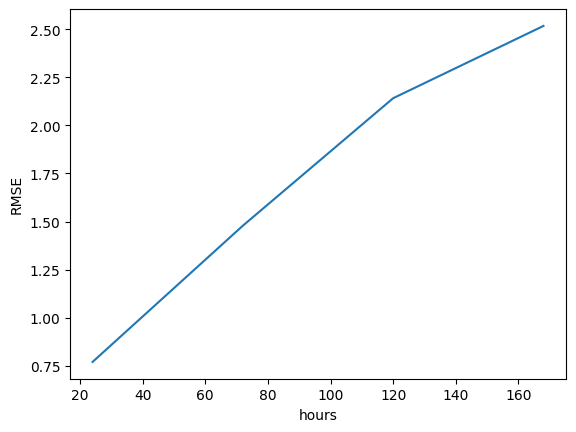

In [149]:
import matplotlib.pyplot as plt

plt.plot(mean_rmses.keys(), mean_rmses.values())
plt.xlabel("hours")
plt.ylabel("RMSE")
plt.show()

In [195]:
denorm_pred = model.reverse_inp_transform(results[datetime(2020, 1, 2, 0, 0)][24]['pred']).to(device)
denorm_gt = model.reverse_inp_transform(results[datetime(2020, 1, 2, 0, 0)][24]['gt']).to(device)

wind_preds = denorm_pred[0, 1]
wind_gt = denorm_gt[0, 1]
diff = wind_preds - wind_gt

In [196]:
pred_np = wind_preds.cpu().numpy()
gt_np = wind_gt.cpu().numpy()
diff_np = diff.cpu().numpy()

v_min = min(pred_np.min(), gt_np.min())
v_max = max(pred_np.max(), gt_np.max())

In [197]:
v_min

np.float32(-20.628555)

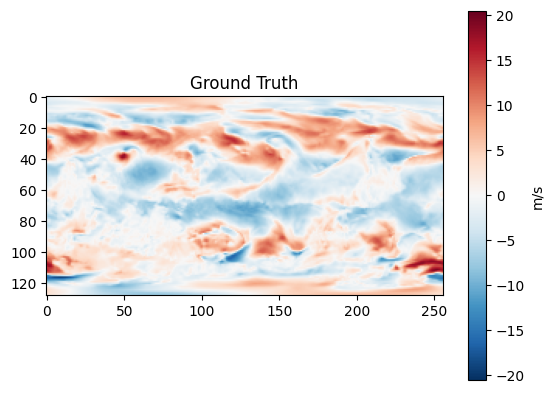

In [198]:
plt.imshow(gt_np, cmap="RdBu_r", vmin=v_min, vmax=v_max)
plt.title("Ground Truth")
plt.colorbar(label="m/s")
plt.show()

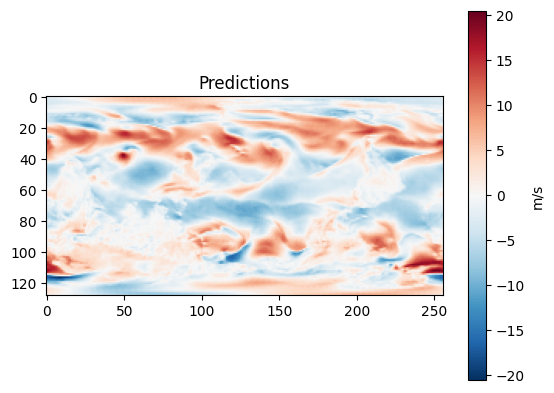

In [199]:
plt.imshow(pred_np, cmap="RdBu_r", vmin=v_min, vmax=v_max)
plt.title("Predictions")
plt.colorbar(label="m/s")
plt.show()

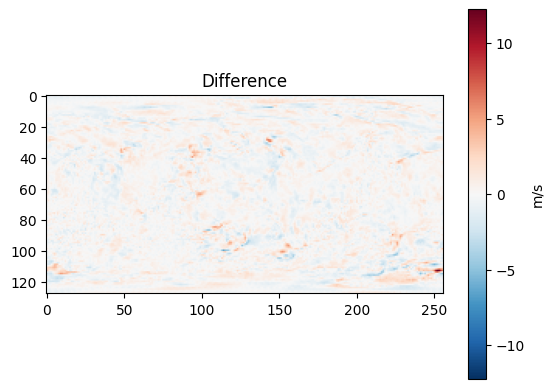

In [200]:
diff_limit = max(abs(diff_np.min()), abs(diff_np.max()))

plt.imshow(diff_np, cmap="RdBu_r", vmin=-diff_limit, vmax=diff_limit)
plt.title("Difference")
plt.colorbar(label="m/s")
plt.show()

In [35]:
results

{datetime.datetime(2020, 1, 1, 0, 0): {24: tensor([[[[-1.4054, -1.4146, -1.4114,  ..., -1.4113, -1.4082, -1.4152],
            [-1.3518, -1.3600, -1.3619,  ..., -1.3584, -1.3642, -1.3685],
            [-1.3288, -1.3316, -1.3343,  ..., -1.3251, -1.3294, -1.3242],
            ...,
            [-1.5078, -1.5155, -1.5196,  ..., -1.5040, -1.5047, -1.5099],
            [-1.5625, -1.5697, -1.5731,  ..., -1.5648, -1.5656, -1.5697],
            [-1.6032, -1.6062, -1.5988,  ..., -1.6090, -1.5982, -1.5956]],
  
           [[-0.3133, -0.3395, -0.2891,  ..., -0.4081, -0.3673, -0.3348],
            [-0.2945, -0.2817, -0.2519,  ..., -0.3522, -0.3322, -0.2553],
            [-0.3676, -0.3801, -0.3558,  ..., -0.4479, -0.4292, -0.4004],
            ...,
            [ 0.2044,  0.1662,  0.1214,  ...,  0.2875,  0.2619,  0.2476],
            [ 0.2127,  0.1705,  0.0796,  ...,  0.3142,  0.2432,  0.2477],
            [ 0.1477,  0.1102,  0.0317,  ...,  0.2484,  0.1778,  0.2191]],
  
           [[-0.8998, -0.9492